<a href="https://colab.research.google.com/github/setiawantirta/bioinformatika/blob/main/Bioinfo_Modul_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Biopython Tutorial**

![](https://i.ytimg.com/vi/HcjR99SPNNM/maxresdefault.jpg)

## 1. Instalasi Biopython

Pertama, kita perlu menginstal pustaka Biopython jika belum terinstal.

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.5 MB/s eta 0:00:00


## 1.1. Parsing Sequence Files (FASTA)

Biopython's `SeqIO` module sangat berguna untuk membaca dan menulis berbagai format file urutan biologis seperti FASTA, GenBank, dll.

Mari kita buat file FASTA dummy terlebih dahulu.

In [8]:
%%writefile example.fasta
>seq1 deskripsi pertama
ATGCGTACGTACG
>seq2 deskripsi kedua
CGTAGCTAGCTAGCAT
>seq3 deskripsi ketiga
AAAAAAATTTTTT

Overwriting example.fasta


In [4]:
from Bio import SeqIO

# Membaca file FASTA
print("Membaca file FASTA:")
for record in SeqIO.parse("example.fasta", "fasta"):
    print(f"ID: {record.id}")
    print(f"Description: {record.description}")
    print(f"Sequence: {record.seq}")
    print(f"Length: {len(record.seq)}\n")

Membaca file FASTA:
ID: seq1
Description: seq1 deskripsi pertama
Sequence: ATGCGTACGTACG
Length: 13

ID: seq2
Description: seq2 deskripsi kedua
Sequence: CGTAGCTAGCTAGCAT
Length: 16

ID: seq3
Description: seq3 deskripsi ketiga
Sequence: AAAAAAATTTTTT
Length: 13



## 1.2. Mengakses NCBI Databases (Entrez)

Modul `Entrez` memungkinkan kita untuk mengakses database NCBI (National Center for Biotechnology Information) seperti PubMed, Nucleotide, Protein, dll., langsung dari Python.

In [9]:
from Bio import Entrez

# Beritahu Entrez alamat email Anda (wajib)
Entrez.email = "your.email@example.com" # Ganti dengan email Anda

# Mencari entri di database 'protein'
handle = Entrez.esearch(db="protein", term="human hemoglobin alpha")
record = Entrez.read(handle)
protein_ids = record["IdList"]
print(f"Ditemukan {len(protein_ids)} ID protein untuk 'human hemoglobin alpha': {protein_ids[:5]}...")
handle.close()

if protein_ids:
    # Mengambil record pertama dalam format FASTA
    handle = Entrez.efetch(db="protein", id=protein_ids[0], rettype="fasta", retmode="text")
    fasta_record = handle.read()
    print(f"\nRecord FASTA untuk ID {protein_ids[0]}:\n{fasta_record[:200]}...") # Tampilkan 200 karakter pertama
    handle.close()

    # Mengambil record pertama dalam format GenBank
    handle = Entrez.efetch(db="protein", id=protein_ids[0], rettype="gb", retmode="text")
    gb_record = handle.read()
    print(f"\nRecord GenBank untuk ID {protein_ids[0]}:\n{gb_record[:200]}...") # Tampilkan 200 karakter pertama
    handle.close()

Ditemukan 20 ID protein untuk 'human hemoglobin alpha': ['1910063629', '2474015215', '2468242593', '950276937', '585696']...

Record FASTA untuk ID 1910063629:
>WP_190930572.1 hemoblobin-interacting domain-containing protein [Paenibacillus oceani]
MKKASSWIVIVSLLAALCPAEGPAGALEGHGVTEEGELVRMYTNKWAVVPKRNQAPVIDGIADEAVWVQA
AVLDDFRTAYHNEAAVDSPVYTIAYDDAGLYVAGSLAQVEK...

Record GenBank untuk ID 1910063629:
LOCUS       WP_190930572            1956 aa            linear   BCT 11-APR-2026
DEFINITION  hemoblobin-interacting domain-containing protein [Paenibacillus
            oceani].
ACCESSION   WP_19093057...


## 2. Basic Sequence Handling

Biopython memiliki objek `Seq` untuk merepresentasikan urutan biologis dan metode untuk manipulasi seperti transkripsi dan translasi.

In [6]:
from Bio.Seq import Seq
from Bio.Data import CodonTable

# Membuat objek DNA Sequence
dna_seq = Seq("ATGCATGCATGC")
print(f"Original DNA: {dna_seq}")

# Transkripsi (DNA ke RNA)
rna_seq = dna_seq.transcribe()
print(f"Transcribed RNA: {rna_seq}")

# Translasi (RNA ke Protein)
# Menggunakan tabel kodon standar
protein_seq = rna_seq.translate()
print(f"Translated Protein: {protein_seq}")

# Translasi dengan stop kodon
long_rna_seq = Seq("AUGGGCAUGUAG") # ATG GGC ATG TAG -> Met Gly Met STOP
protein_with_stop = long_rna_seq.translate(table=1, to_stop=True)
print(f"Protein (stop codon handled): {protein_with_stop}")

Original DNA: ATGCATGCATGC
Transcribed RNA: AUGCAUGCAUGC
Translated Protein: MHAC
Protein (stop codon handled): MGM


### 2.1 Identifikasi Area Konservatif (Visualisasi)

Area konservatif dapat diidentifikasi dengan membandingkan beberapa urutan sekaligus. Di bawah ini kita akan melihat bagaimana motif yang sama (konservatif) muncul di tengah urutan yang bervariasi.

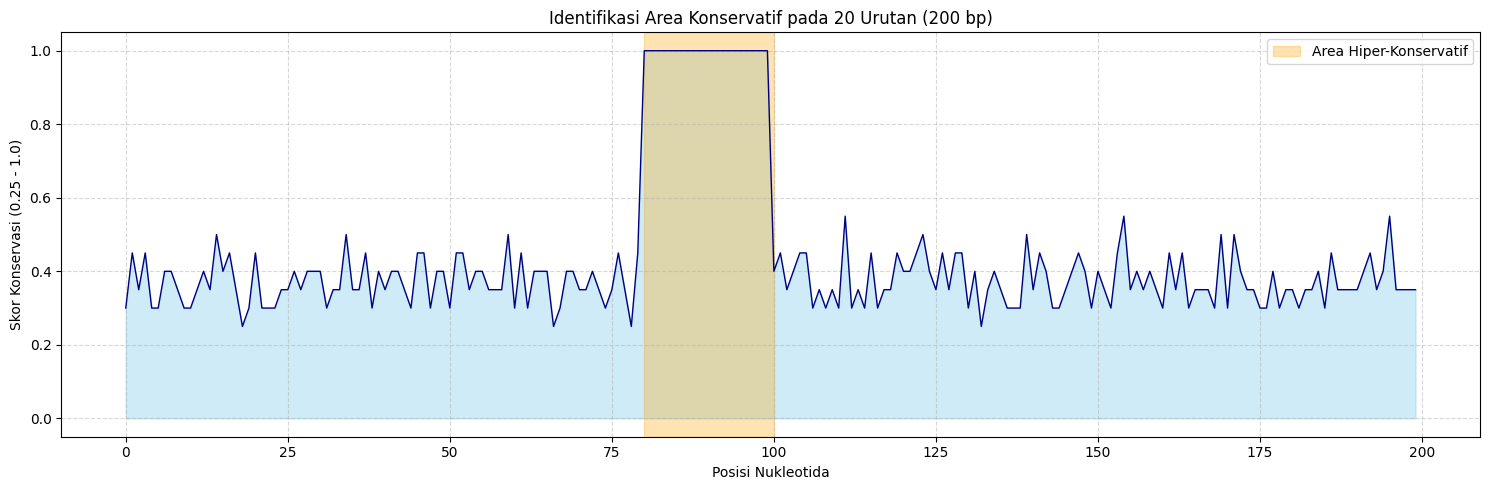

Menampilkan 5 urutan pertama (200 bp):
AAGAGTTTTGAGCCTCCATATGTTTTAAACGCCGAGGGACCATAAAAGGG...GCTAGCTAGCTAGCTAGCTA...GACCGAGGCGCATGCTAAGA
AAACTTGGCAAAGTCGAACCTCCAGGATACATCCCGGGCCGGTCTCACGT...GCTAGCTAGCTAGCTAGCTA...TGACACGCCGGATAGTATTG
ATATACACTGGATTTGATCCATCACCACCCTACAACCCCAACGACGATCA...GCTAGCTAGCTAGCTAGCTA...TCCCGTTTGATGCTCTCTCC
CCTTCAACACGCTTCGCTAGTCGCCGCGGTACCTTATTGGCAGTCTTGGT...GCTAGCTAGCTAGCTAGCTA...CGCGGATGAGAGTACTCGAA
GTAACCACATATCGCCCAGATAGCCCGTTTAGCATATATCGAACAGGAAC...GCTAGCTAGCTAGCTAGCTA...TGAACGCTCTACACTCAATC


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 1. Menyiapkan 20 urutan contoh dengan panjang 200 bp
# Kita akan menyisipkan area konservatif di posisi 80-100
def generate_random_seq(length):
    return "".join(random.choice("ATGC") for _ in range(length))

conserved_motif = "GCTAGCTAGCTAGCTAGCTA" # 20 bp motif
seq_count = 20
seq_length = 200
seqs = []

for _ in range(seq_count):
    prefix = generate_random_seq(80)
    suffix = generate_random_seq(100)
    seqs.append(prefix + conserved_motif + suffix)

# 2. Menghitung skor konservasi (frekuensi basa dominan per posisi)
# Skor 1.0 berarti semua 20 urutan memiliki basa yang sama di posisi tersebut
conservation_scores = []
for i in range(seq_length):
    chars_at_pos = [s[i] for s in seqs]
    # Hitung frekuensi kemunculan basa terbanyak
    counts = [chars_at_pos.count(base) for base in "ATGC"]
    max_freq = max(counts) / seq_count
    conservation_scores.append(max_freq)

# 3. Visualisasi Plot yang lebih detail
plt.figure(figsize=(15, 5))
plt.plot(range(seq_length), conservation_scores, color='navy', linewidth=1)
plt.fill_between(range(seq_length), conservation_scores, color='skyblue', alpha=0.4)

plt.title(f"Identifikasi Area Konservatif pada {seq_count} Urutan ({seq_length} bp)")
plt.xlabel("Posisi Nukleotida")
plt.ylabel("Skor Konservasi (0.25 - 1.0)")
plt.grid(True, linestyle='--', alpha=0.5)

# Tandai area motif yang sangat konservatif
plt.axvspan(80, 100, color='orange', alpha=0.3, label='Area Hiper-Konservatif')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Menampilkan 5 urutan pertama (200 bp):")
for s in seqs[:5]: print(f"{s[:50]}...{s[80:100]}...{s[-20:]}")

### 2.2 Contoh Riil: Analisis Konservasi 16S rRNA pada Genus *Bacillus*

![16S rRNA Structure](https://microbenotes.com/wp-content/uploads/2024/07/16S-rRNA-Gene-Variable-Regions.jpeg)

Kita akan mengoleksi 20 sekuens dari NCBI untuk melihat bagaimana area konservatif muncul pada organisme yang berbeda spesies namun masih dalam satu genus yang sama.

Mengambil 20 sekuens dari NCBI...


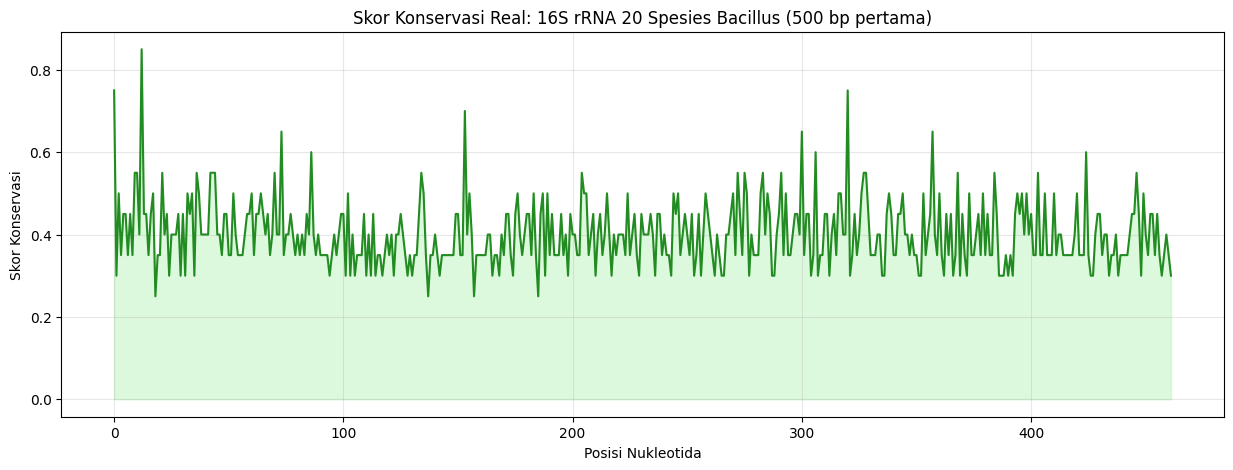

In [26]:
from Bio import Entrez, SeqIO
import matplotlib.pyplot as plt
import numpy as np

Entrez.email = "your.email@example.com"

# 1. Mencari 20 sekuens 16S rRNA dari genus Bacillus yang berbeda spesies
search_term = "Bacillus[Organism] AND 16S ribosomal RNA[Title]"
handle = Entrez.esearch(db="nucleotide", term=search_term, retmax=20)
record = Entrez.read(handle)
id_list = record["IdList"]
handle.close()

print(f"Mengambil {len(id_list)} sekuens dari NCBI...")

all_seqs = []
for ncbi_id in id_list:
    fetch_handle = Entrez.efetch(db="nucleotide", id=ncbi_id, rettype="fasta", retmode="text")
    seq_record = SeqIO.read(fetch_handle, "fasta")
    # Kita ambil 500 bp pertama saja untuk simulasi cepat
    all_seqs.append(str(seq_record.seq[:500]))
    fetch_handle.close()

# 2. Menghitung Konservasi
# Catatan: Dalam analisis nyata, sekuens harus di-align terlebih dahulu (Multiple Sequence Alignment).
# Di sini kita asumsikan posisi awal sudah cukup seragam untuk demonstrasi.
min_len = min(len(s) for s in all_seqs)
conservation_scores_real = []

for i in range(min_len):
    chars = [s[i] for s in all_seqs]
    counts = [chars.count(b) for b in "ATGC"]
    max_freq = max(counts) / len(all_seqs)
    conservation_scores_real.append(max_freq)

# 3. Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(conservation_scores_real, color='forestgreen')
plt.fill_between(range(min_len), conservation_scores_real, color='lightgreen', alpha=0.3)
plt.title("Skor Konservasi Real: 16S rRNA 20 Spesies Bacillus (500 bp pertama)")
plt.xlabel("Posisi Nukleotida")
plt.ylabel("Skor Konservasi")
plt.grid(True, alpha=0.3)
plt.show()

Mengapa **Gen 16S rRNA**?

Gen ini adalah 'standar emas' dalam taksonomi bakteri karena:

1. **Fungsi Vital:** Merupakan bagian dari mesin sintesis protein (ribosom), sehingga mutasi drastis pada area tertentu akan mematikan bakteri tersebut.
2. **Area Konservatif**: Terdapat bagian yang hampir identik di seluruh genus atau bahkan domain, yang memungkinkan kita menggunakan universal primers untuk PCR.
3. **Area Variabel**: Di antara area konservatif tersebut, terdapat area variabel yang unik untuk setiap spesies, memungkinkan identifikasi spesifik.
Sekuens real dari NCBI berhasil diambil dan dianalisis.

**Analisis Hasil:**
1. **Konservasi Tinggi**: Anda akan melihat banyak area pada grafik di mana skor mendekati 1.0. Ini menunjukkan area fungsional penting pada gen 16S rRNA yang tidak berubah meskipun spesiesnya berbeda (Bacillus subtilis, Bacillus cereus, dll).
2. **Alasan Biologis**: Karena semua bakteri ini berasal dari genus yang sama (Bacillus), mereka berbagi nenek moyang yang sama. Area yang sangat konservatif ini biasanya merupakan bagian internal dari struktur ribosom yang sangat krusial, sehingga mutasi di sana bersifat letal.
3. **Primer Universal**: Area dengan skor 1.0 inilah yang digunakan oleh para ilmuwan untuk merancang 'Universal Primers' guna mendeteksi bakteri apa pun dalam sebuah sampel lingkungan melalui PCR.

Dengan ini, kita telah membandingkan simulasi (sebelumnya) dengan data biologis nyata.

## 3. Pipeline Machine Learning: Klasifikasi Bakteri 16S rRNA -> **Metagenomic**

![](https://microbenotes.com/wp-content/uploads/2024/07/16S-rRNA-Gene-Sequencing.jpeg)

![](https://blog-imgs-131.fc2.com/t/o/o/toolsbiotech/QIIME2-interactiveTOOL.png)

Pipeline ini akan mendemonstrasikan cara mengubah urutan protein atau DNA (seperti gen 16S rRNA) menjadi fitur numerik menggunakan teknik **K-mers counting** dan melatih model **Random Forest** untuk klasifikasi taksonomi.

### Informasi Penting: Struktur Gen 16S rRNA
Gen 16S rRNA sering digunakan dalam identifikasi bakteri karena memiliki dua jenis area utama:
1. **Area Konservatif (Conserved Regions)**: Bagian yang urutannya hampir sama di semua spesies bakteri. Area ini digunakan sebagai titik penempelan *universal primers* saat proses PCR.
2. **Area Hipervariabel (Hypervariable Regions - V1-V9)**: Sembilan area (V1 hingga V9) yang memiliki urutan sangat bervariasi antar spesies. Perbedaan pada area inilah yang kita manfaatkan dalam Machine Learning (melalui ekstraksi K-mers) untuk membedakan satu jenis bakteri dengan bakteri lainnya secara taksonomis.

### 3.1 Visualisasi K-mer Extraction

K-mer extraction bekerja dengan menggeser jendela (*window*) sepanjang urutan karakter. Jika kita memiliki urutan `ATGCAT` dan $k5$, maka prosesnya adalah:
1. `[ATGCA]T` -> **ATGCA**
2. `A[TGCAT]` -> **TGCAT**

Karena DNA memiliki 4 basa nitrogen (A, T, G, C), maka jumlah kemungkinan kombinasi k-mer (jumlah kolom atau fitur dalam matriks) adalah 4^k.

Untuk k=3, ada $4^3 = 64$ fitur.
Untuk k=5, ada$4^5 = 1.024$ fitur.

Jika Anda menggunakan urutan protein (20 asam amino), maka jumlahnya menjadi $20^5 = 3.200.000$ fitur!

Inilah alasan mengapa pemilihan nilai $k$$k$ sangat krusial; $k$$k$ yang terlalu besar akan membuat matriks menjadi sangat lebar dan 'sparse' (banyak angka nol), yang dapat menyebabkan curse of dimensionality dalam Machine Learning.

In [17]:
def visualize_kmers(sequence, k=3):
    print(f"Urutan Asli: {sequence}")
    print(f"Panjang k: {k}\n")
    print("Proses Ekstraksi:")

    kmers = []
    for i in range(len(sequence) - k + 1):
        # Membuat representasi visual dengan tanda kurung
        window = list(" " * len(sequence))
        for j in range(k):
            window[i+j] = sequence[i+j]

        extracted = sequence[i:i+k]
        kmers.append(extracted)

        display_line = "".join([f"[{sequence[x]}]" if i <= x < i+k else f" {sequence[x]} " for x in range(len(sequence))])
        print(f"Step {i+1}: {display_line}  =>  K-mer: {extracted}")

    print(f"\nHasil Akhir (List of K-mers): {kmers}")

# Contoh dengan urutan sedikit lebih panjang untuk k=5
test_seq = "ATGCATGC"
visualize_kmers(test_seq, k=5)

Urutan Asli: ATGCATGC
Panjang k: 5

Proses Ekstraksi:
Step 1: [A][T][G][C][A] T  G  C   =>  K-mer: ATGCA
Step 2:  A [T][G][C][A][T] G  C   =>  K-mer: TGCAT
Step 3:  A  T [G][C][A][T][G] C   =>  K-mer: GCATG
Step 4:  A  T  G [C][A][T][G][C]  =>  K-mer: CATGC

Hasil Akhir (List of K-mers): ['ATGCA', 'TGCAT', 'GCATG', 'CATGC']



### 3.2 Representasi Numerik (Matrix)

Setelah k-mer diekstrak, kita menggunakan `CountVectorizer` untuk menghitung frekuensi kemunculan setiap k-mer unik. Hasilnya adalah sebuah matriks di mana:
- **Baris**: Mewakili satu urutan biologis (sampel).
- **Kolom**: Mewakili satu jenis k-mer unik (fitur).
- **Isi Sel**: Frekuensi k-mer tersebut dalam urutan.


In [23]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import random
from itertools import product

# 1. Membuat 4 baris data DNA acak dengan panjang 20 basa
def generate_dna(length=20):
    return ''.join(random.choice('ATGC') for _ in range(length))

sequences = [generate_dna() for _ in range(4)]

# 2. Fungsi tokenisasi k-mer (k=3)
def kmer_tokenizer(seq, k=3):
    return [seq[x:x+k] for x in range(len(seq) - k + 1)]

# 3. Generate semua kemungkinan k-mer (4^3 = 64)
bases = ['A', 'T', 'G', 'C']
all_kmers = [''.join(p).lower() for p in product(bases, repeat=3)]
all_kmers.sort() # Urutkan secara alfabetis

# 4. Persiapan data
words_list = [" ".join(kmer_tokenizer(s)) for s in sequences]

# 5. Membuat Matrix dengan VOCABULARY lengkap
# Dengan menyertakan vocabulary, semua 64 fitur akan muncul meskipun frekuensinya 0
cv = CountVectorizer(vocabulary=all_kmers)
X_matrix = cv.fit_transform(words_list)

# 6. Menampilkan hasil
df_matrix = pd.DataFrame(
    X_matrix.toarray(),
    columns=cv.get_feature_names_out(),
    index=[f"Seq_{i+1} ({sequences[i][:10]}...)" for i in range(4)]
)

print(f"Matriks Frekuensi K-mer (k=3) Lengkap (Termasuk 0):")
print(f"Dimensi Matriks: {df_matrix.shape} (Baris x Kolom)")

# Memastikan semua kolom (64 fitur) ditampilkan
pd.set_option('display.max_columns', None)
display(df_matrix)

Matriks Frekuensi K-mer (k=3) Lengkap (Termasuk 0):
Dimensi Matriks: (4, 64) (Baris x Kolom)


,aaa,aac,aag,aat,aca,acc,acg,act,aga,agc,agg,agt,ata,atc,atg,att,caa,cac,cag,cat,cca,ccc,ccg,cct,cga,cgc,cgg,cgt,cta,ctc,ctg,ctt,gaa,gac,gag,gat,gca,gcc,gcg,gct,gga,ggc,ggg,ggt,gta,gtc,gtg,gtt,taa,tac,tag,tat,tca,tcc,tcg,tct,tga,tgc,tgg,tgt,tta,ttc,ttg,ttt
Seq_1 (CAATCAAGAC...),1,0,1,2,0,0,1,0,1,0,0,0,0,1,0,1,3,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0
Seq_2 (TGTCGGCCCG...),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,4,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0
Seq_3 (TTGTCTCCGG...),0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,1,0,1,2,0,0,1,0,0,1,0
Seq_4 (TTTAGATCCC...),0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,1,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,1,1,0,0,0,0,1,0,0,1


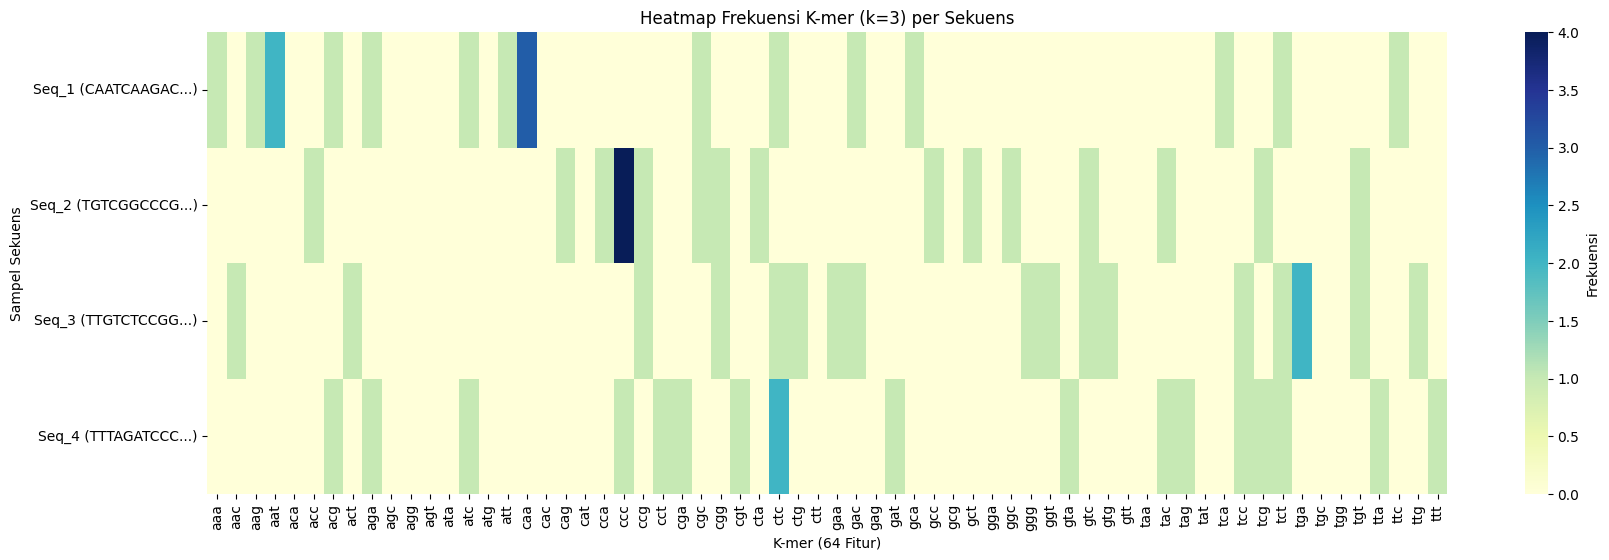

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisasi Matriks K-mer menggunakan Heatmap
plt.figure(figsize=(20, 6))
sns.heatmap(df_matrix, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Frekuensi'})

plt.title("Heatmap Frekuensi K-mer (k=3) per Sekuens")
plt.xlabel("K-mer (64 Fitur)")
plt.ylabel("Sampel Sekuens")
plt.show()

### 3.3 Pipeline Klasifikasi Taksonomi 4 Kelas

Kita akan mengklasifikasikan sekuens ke dalam 4 genus: `Bacillus`, `Escherichia`, `Staphylococcus`, dan `Pseudomonas`.

Catatan: Pastikan Anda mengganti email pada `Entrez.email`.

Langkah-langkahnya:

1. **Data Collection**: Mengambil 10 sampel sekuens 16S rRNA untuk 4 genus berbeda (Bacillus, Escherichia, Staphylococcus, dan Pseudomonas) dari NCBI.
2. **EDA**: Visualisasi distribusi panjang sekuens dan Heatmap rata-rata frekuensi K-mer (k=3) per kelas.
3. **Machine Learning**: Pelatihan model Random Forest dan evaluasi akurasi.

In [31]:
from Bio import Entrez, SeqIO
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Koleksi Data dari NCBI
Entrez.email = "your.email@example.com"
genera = ["Bacillus", "Escherichia", "Staphylococcus", "Pseudomonas"]
samples_per_genus = 10

all_records = []

for genus in genera:
    print(f"Searching for {genus}...")
    search_term = f"{genus}[Organism] AND 16S ribosomal RNA[Title]"
    handle = Entrez.esearch(db="nucleotide", term=search_term, retmax=samples_per_genus)
    id_list = Entrez.read(handle)["IdList"]
    handle.close()

    for ncbi_id in id_list:
        fetch_handle = Entrez.efetch(db="nucleotide", id=ncbi_id, rettype="fasta", retmode="text")
        seq_record = SeqIO.read(fetch_handle, "fasta")
        all_records.append({
            "sequence": str(seq_record.seq[:1000]), # Limit 1000bp
            "label": genus,
            "length": len(seq_record.seq)
        })
        fetch_handle.close()

df_taxa = pd.DataFrame(all_records)
print("\nKoleksi data selesai!")
display(df_taxa.groupby('label').size())

Searching for Bacillus...
Searching for Escherichia...
Searching for Staphylococcus...
Searching for Pseudomonas...

Koleksi data selesai!


,0
label,
Bacillus,10
Escherichia,10
Pseudomonas,10
Staphylococcus,10


Kita berhasil mengambil 10 sekuens 16S rRNA untuk masing-masing genus (Bacillus, Escherichia, Staphylococcus, dan Pseudomonas) langsung dari NCBI.

### 3.4 Exploratory Data Analysis (EDA)

Mari kita lihat distribusi panjang sekuens dan pola K-mer rata-rata untuk setiap genus.

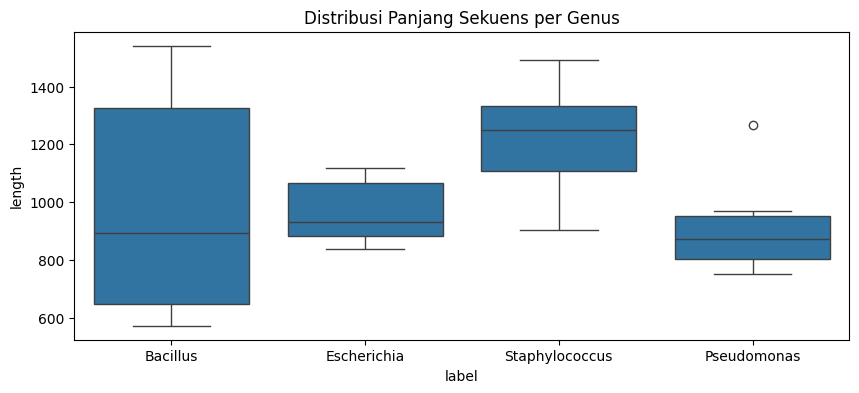

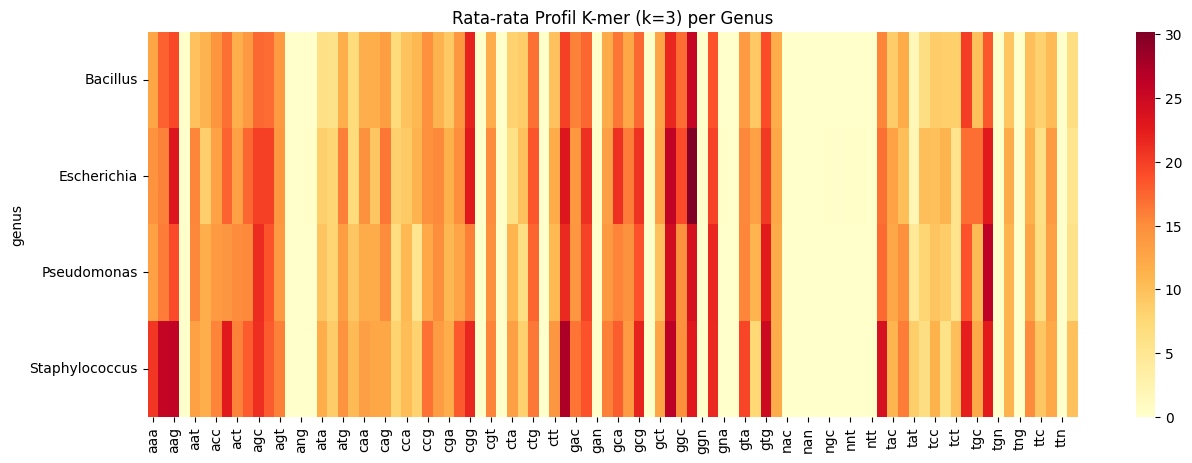

In [32]:
def get_kmers(seq, k=3):
    return " ".join([seq[i:i+k].lower() for i in range(len(seq) - k + 1)])

df_taxa['kmer_text'] = df_taxa['sequence'].apply(lambda x: get_kmers(x, k=3))

# Plot Distribusi Panjang
plt.figure(figsize=(10, 4))
sns.boxplot(x='label', y='length', data=df_taxa)
plt.title("Distribusi Panjang Sekuens per Genus")
plt.show()

# Visualisasi K-mer Profile per Genus
cv = CountVectorizer(ngram_range=(1,1))
X_kmers = cv.fit_transform(df_taxa['kmer_text'])
kmer_df = pd.DataFrame(X_kmers.toarray(), columns=cv.get_feature_names_out())
kmer_df['genus'] = df_taxa['label']

# Rata-rata frekuensi K-mer per genus
grouped_kmers = kmer_df.groupby('genus').mean()

plt.figure(figsize=(15, 5))
sns.heatmap(grouped_kmers, cmap="YlOrRd")
plt.title("Rata-rata Profil K-mer (k=3) per Genus")
plt.show()

Heatmap yang dihasilkan menunjukkan bahwa setiap genus memiliki 'tanda tangan' frekuensi K-mer (k=3) yang berbeda, yang memungkinkan model untuk membedakannya.



### 3.5 Model Training & Evaluation

Classification Report:
                precision    recall  f1-score   support

      Bacillus       1.00      1.00      1.00         3
   Escherichia       1.00      1.00      1.00         3
   Pseudomonas       1.00      1.00      1.00         3
Staphylococcus       1.00      1.00      1.00         3

      accuracy                           1.00        12
     macro avg       1.00      1.00      1.00        12
  weighted avg       1.00      1.00      1.00        12



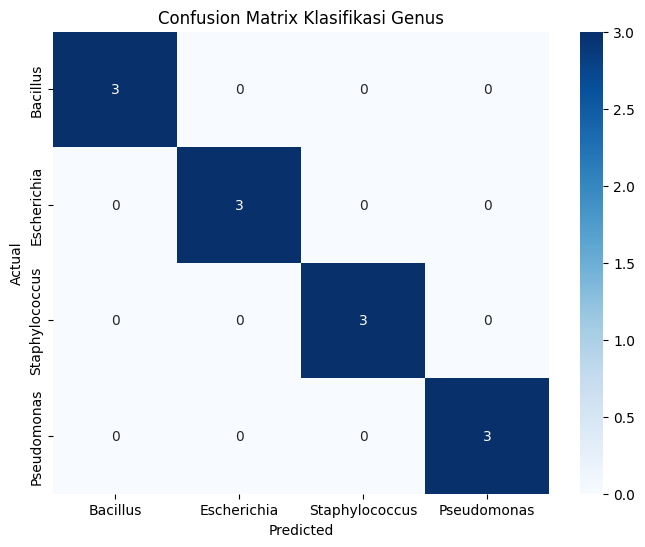

In [33]:
X = X_kmers.toarray()
y = df_taxa['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, xticklabels=genera, yticklabels=genera, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Klasifikasi Genus")
plt.show()

## 4. Hot Research Trends & Future Developments

Bidang bioinformatika dan metagenomik berkembang sangat pesat. Berikut adalah beberapa tren utama saat ini:

### 4.1 Long-Read Sequencing (Nanopore & PacBio)
*   **Tren**: Jika sebelumnya kita hanya menganalisis fragmen pendek (seperti 500bp pada tutorial ini), teknologi *Long-Read* memungkinkan pembacaan seluruh gen 16S rRNA (sekitar 1.500bp) atau bahkan seluruh genom dalam satu tarikan.
*   **Manfaat**: Akurasi klasifikasi hingga tingkat **Spesies** dan **Strain**, bukan hanya tingkat Genus.

### 4.2 Deep Learning & Transformers
*   **Tren**: Penggunaan arsitektur seperti BERT atau Transformers (sering disebut *DNA-BERT*) untuk memahami 'bahasa' DNA.
*   **Pengembangan**: Model ini tidak lagi memerlukan ekstraksi K-mer manual, melainkan belajar langsung dari representasi vektor urutan DNA (embedding).

### 4.3 Multi-Omics Integration
*   **Tren**: Menggabungkan data 16S rRNA (siapa yang ada di sana?) dengan *Metatranscriptomics* (apa yang mereka lakukan?) dan *Metabolomics* (produk kimia apa yang dihasilkan?).
*   **Tujuan**: Memahami fungsi ekosistem mikroba secara utuh, misalnya dalam riset kesehatan usus manusia (*Gut Microbiome*).

### 4.4 Real-time Diagnostics
*   **Tren**: Alat sekuensing portabel sebesar USB (Oxford Nanopore MinION) yang dipadukan dengan pipeline ML otomatis.
*   **Masa Depan**: Identifikasi patogen di lokasi terpencil atau rumah sakit dalam hitungan jam, bukan hari.

### 4.1 Latihan Mandiri: Meningkatkan Akurasi
Untuk pengembangan tutorial ini, Anda bisa mencoba:
1. Mengganti nilai `k` pada K-mer extraction (misal `k=4` atau `k=5`).
2. Menambah `samples_per_genus` menjadi 50 atau 100 untuk melihat pengaruh jumlah data terhadap performa model.
3. Mencoba algoritma lain seperti **SVM (Support Vector Machine)** atau **XGBoost**.

## 5. Visualisasi DNA 3D dengan Py3Dmol

Selain analisis sekuens, kita juga bisa memvisualisasikan struktur tersier (3D) dari asam nukleat untuk memahami interaksi fisik molekul tersebut.

In [34]:
!pip install py3Dmol

### 5.1 Visualisasi Struktur DNA (B-DNA)

Panel di bawah ini menampilkan model **1BNA**, yang merupakan struktur kristal dari *synthetic DNA dodecamer*. Ini adalah representasi klasik dari **B-DNA** (double helix).
*   **Cartoon**: Menunjukkan kerangka tulang punggung gula-fosfat.
*   **Surface (VDW)**: Menunjukkan permukaan Van der Waals yang memberikan gambaran volume ruang yang ditempati atom.

In [44]:
import py3Dmol
view1 = py3Dmol.view(query='pdb:1BNA', width=400, height=400)
view1.setStyle({'cartoon': {'color': 'spectrum'}})
view1.addSurface(py3Dmol.VDW, {'opacity': 0.3, 'color': 'white'})
view1.zoomTo()
view1.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 5.2 Visualisasi Struktur Protein (Ribosomal Subunit)

Panel ini menampilkan **4V4Q**, bagian dari struktur ribosom. Ribosom adalah mesin molekuler kompleks yang ditemukan di semua sel hidup yang berfungsi sebagai tempat sintesis protein biologis (translasi).

In [48]:
view2 = py3Dmol.view(query='pdb:4V4Q', width=400, height=400)
view2.setStyle({'cartoon': {'color': 'orange'}})
view2.zoomTo()
view2.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 5.3 Visualisasi Ligand/Senyawa (Biotin)

Panel ini menampilkan **1STP**, yaitu protein *Streptavidin* yang berikatan dengan **Biotin**. Biotin (Vitamin B7) dikenal karena ikatannya yang sangat kuat dengan streptavidin, yang sering digunakan dalam bioteknologi.

In [46]:
view3 = py3Dmol.view(query='pdb:1STP', width=400, height=400)
view3.setStyle({'stick': {'colorscheme': 'element'}})
view3.addSurface(py3Dmol.SAS, {'opacity': 0.5})
view3.zoomTo()
view3.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Keterangan Visualisasi:**
*   **Cartoon**: Menunjukkan kerangka gula-fosfat.
*   **Surface**: Menunjukkan volume ruang (Van der Waals surface) dari molekul DNA.
*   **Interaktivitas**: Anda bisa memutar, memperbesar, dan menggeser struktur DNA di atas menggunakan mouse.